# Module 2 - Regression

## Problem Framing

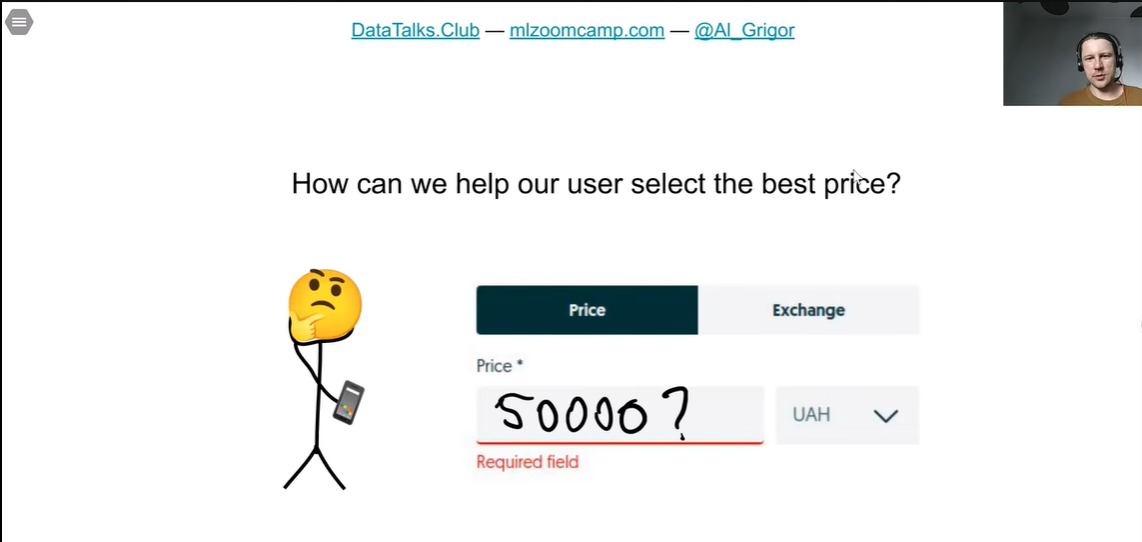

### Project Plan

1. Prepare data and EDA (Exploratory Data Analysis)
2. Use linear regression for predicting the price
3. Understand the internals of linear regression
4. Evaluating the model with RMSE (Root Mean Squared Error)
5. Feature engineering
6. Regularization
7. Use the model

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

### Download the dataset

`wget` is a way for downloading files using the command line

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

# -nc means "no clobber": wget skips the download if the file already exists
!wget -nc $data

File ‘data.csv’ already there; not retrieving.



### Load the dataset

`MSRP` is the prediction target

In [5]:
df = pd.read_csv('data.csv')

# Preview first few rows
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Cleaning the data

In [6]:
# Column names are inconsistent (mixed case, spaces)
# We need to standardize these
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [7]:
# Turn column names into snake case (lowercase, underscores instead of spaces)
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [8]:
# Looking at the values of our categorical columns, we can see that they're inconsistent as well
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [9]:
# First, we need to identify the str columns
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [14]:
# Get the list of str columns
str_columns = list(df.dtypes[df.dtypes == 'str'].index)

str_columns

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [15]:
# Automate the process of standardizing the values in the str columns
for col in str_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## Exploratory Data Analysis (EDA)

### Preview data

In [20]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Summary info

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

### Unique values per column

In [29]:
# Check unique values per column
for col in df.columns:
    print(f'Column: {col}')
    print(f'Unique values: {df[col].nunique()}')
    print(f'Sample values: {df[col].unique()[:5].tolist()}')
    print()

Column: make
Unique values: 48
Sample values: ['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']

Column: model
Unique values: 914
Sample values: ['1_series_m', '1_series', '100', '124_spider', '190-class']

Column: year
Unique values: 28
Sample values: [2011, 2012, 2013, 1992, 1993]

Column: engine_fuel_type
Unique values: 10
Sample values: ['premium_unleaded_(required)', 'regular_unleaded', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']

Column: engine_hp
Unique values: 356
Sample values: [335.0, 300.0, 230.0, 320.0, 172.0]

Column: engine_cylinders
Unique values: 9
Sample values: [6.0, 4.0, 5.0, 8.0, 12.0]

Column: transmission_type
Unique values: 5
Sample values: ['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']

Column: driven_wheels
Unique values: 4
Sample values: ['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']

Column: number_of_doors
Unique values: 3
Sample values: [2.0, 4.0, 3.0, nan]

Column: mar

### Distribution of the target (MSRP)

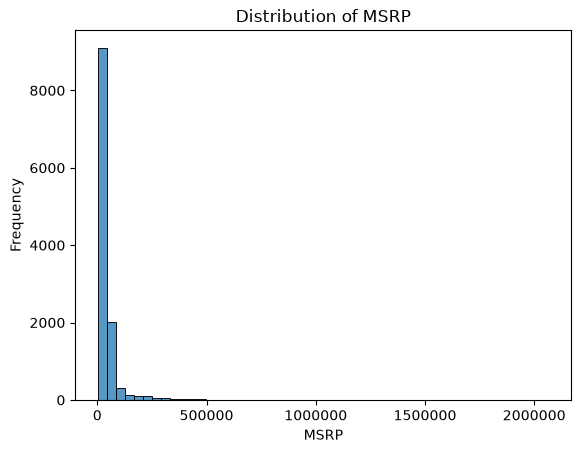

In [54]:
sns.histplot(data=df, x='msrp', bins=50)

plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.title('Distribution of MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

### Long-tail distribution

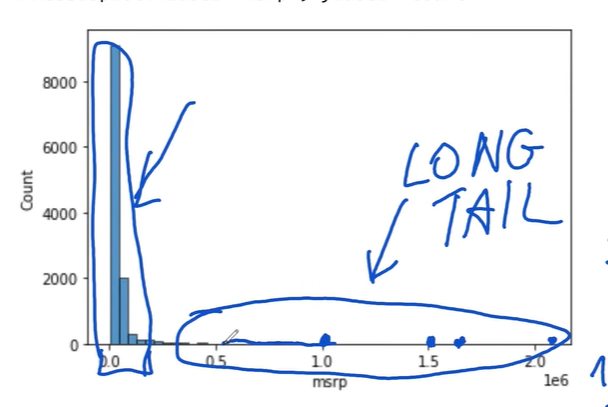

Most of the data is concentrated on the left side. This means most of our car prices are on the lower end of the range.

However, there are a few values on the right side, causing something called a **long-tailed distribution**. This represents very expensive luxury/sports cars.

In [55]:
df.nlargest(10, 'msrp')[['make', 'model', 'msrp']]

,make,model,msrp
11362,bugatti,veyron_16.4,2065902
11364,bugatti,veyron_16.4,1705769
8486,lamborghini,reventon,1500000
11363,bugatti,veyron_16.4,1500000
6351,maybach,landaulet,1382750
6350,maybach,landaulet,1380000
4024,ferrari,enzo,643330
1622,lamborghini,aventador,548800
1626,lamborghini,aventador,548800
1629,lamborghini,aventador,535500


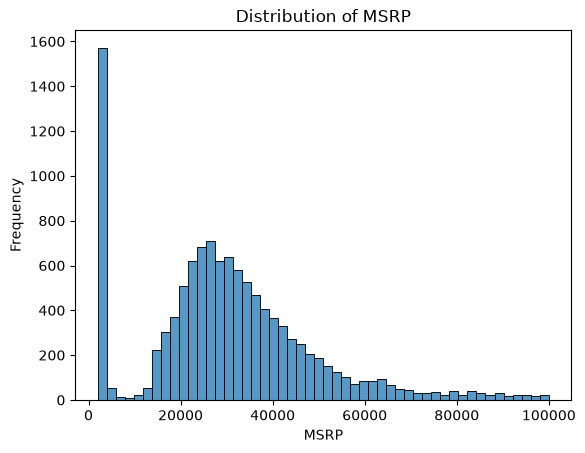

In [56]:
sns.histplot(df[df['msrp'] < 100000], x='msrp', bins=50)
plt.title('Distribution of MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

Zoomed in on cars under $100k to see the shape of "normal" cars. The few luxury cars above $100k (Bugatti, Lamborghini, Maybach, Ferrari) stretch the full chart, so they are hidden here.

- Most cars cost **$20k to $40k**, with a peak near **$25k to $30k**.
- The distribution is still **right-skewed**.
- There is a **spike near $2,000** (about 1,500 cars). New cars don't cost this little, so it is likely a placeholder value. **To check.**

### Apply logarithmic transformation

**IMPORTANT:** 

This distribution is not good for our model. A few very expensive cars would dominate the fit, so the model would predict normal cars worse.

The solution is to apply a **logarithmic transformation** to reduce the long tail.

Log doesn't work on 0, so we add 1 to every price first. NumPy does both steps in one function: `np.log1p()`.

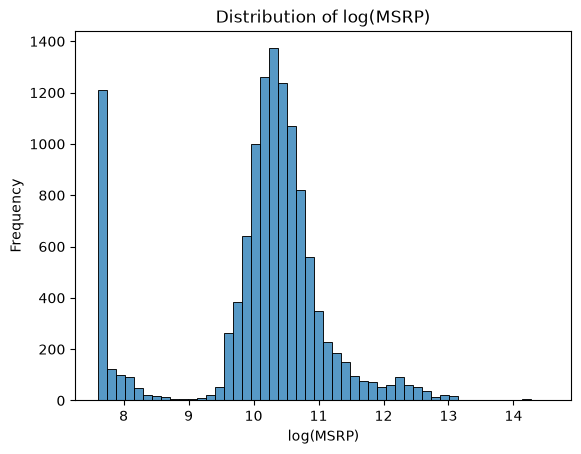

In [60]:
msrp_log = np.log1p(df['msrp'])

sns.histplot(msrp_log, bins=50)
plt.title('Distribution of log(MSRP)')
plt.xlabel('log(MSRP)')
plt.ylabel('Frequency')
plt.show()

After the log transformation, the distribution now looks like a **bell curve of the normal distribution**.

Linear regression works better when the target resembles a normal distribution.

### Spot Missing Values

In [62]:
# Check missing values across columns
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Validation Framework

We will need to split up our dataset into 3 parts:

- Training
- Validation
- Test

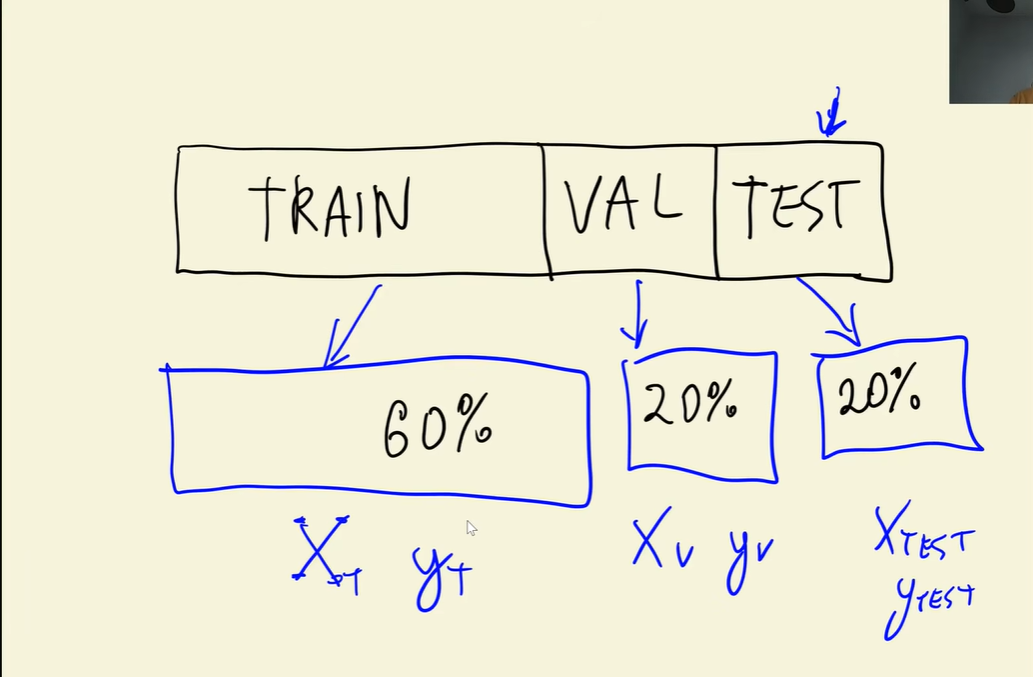

### Compute how many records to include in each split

In [68]:
n = len(df) # Total number of rows in the dataset

n_val = int(n * 0.2) # 20% for validation
n_test = int(n * 0.2) # 20% for testing
n_train = n - n_val - n_test # The rest for training (60%)

print(f'full={n}, train={n_train}, val={n_val}, test={n_test}')

full=11914, train=7150, val=2382, test=2382


### Split the data

In [87]:
df_train = df[:n_train].copy()

print(f'Train set shape: {df_train.shape}')

Train set shape: (7150, 16)


In [88]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [89]:
df_val = df[n_train:n_train+n_val].copy()

print(f'Validation set shape: {df_val.shape}')

Validation set shape: (2382, 16)


In [90]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560


In [91]:
df_test = df[n_val:n_val+n_test].copy()

print(f'Test set shape: {df_test.shape}')

Test set shape: (2382, 16)


In [92]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2382,porsche,cayenne,2017,premium_unleaded_(required),570.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,high-performance",midsize,4dr_suv,21,14,1715,159600
2383,porsche,cayenne,2017,premium_unleaded_(required),420.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,performance",midsize,4dr_suv,24,17,1715,76200
2384,porsche,cayman_s,2006,premium_unleaded_(required),295.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,26,18,1715,58900
2385,porsche,cayman,2014,premium_unleaded_(required),275.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,30,20,1715,52600
2386,porsche,cayman,2014,premium_unleaded_(required),325.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,1715,63800


### Shuffle the data

Now we have a problem: the data is sequential (e.g., ome car makes could only belong in one split but be absent in the others)

The solution is to **shuffle our dataset**.

In [103]:
# Step 1: Create indexes
idx = np.arange(n)

idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [104]:
# Step 2: Set the random seed for reproducibility
np.random.seed(2)

In [105]:
# Step 3: Shuffle the indexes
np.random.shuffle(idx)

idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [106]:
df_train = df.iloc[idx[:n_train]].copy()

print(f'Train set shape: {df_train.shape}')

Train set shape: (7150, 16)


In [107]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [108]:
df_val = df.iloc[idx[n_train:n_train+n_val]].copy()

print(f'Validation set shape: {df_val.shape}')

Validation set shape: (2382, 16)


In [109]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
10498,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
1880,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995


In [110]:
df_test = df.iloc[idx[n_train+n_val:]].copy()

print(f'Test set shape: {df_test.shape}')

Test set shape: (2382, 16)


In [111]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11195,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
673,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
11270,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
752,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
3137,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


### Reset the indexes

In [112]:
df_train = df_train.reset_index(drop=True)

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [113]:
df_val = df_val.reset_index(drop=True)

df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995


In [114]:
df_test = df_test.reset_index(drop=True)

df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
1,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
2,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
3,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
4,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905


### Extract the target variable

In [115]:
# Since the the target variable (msrp) is skewed, we will apply a log transformation to it
y_train = np.log1p(df_train['msrp'].values)
y_train[:5]

array([ 9.57574708,  9.887663  ,  9.89323518,  7.60140233, 10.93775686])

In [116]:
y_val = np.log1p(df_val['msrp'].values)
y_val[:5]

array([10.19936098, 10.90872279,  9.72770457, 10.65963301, 10.16569796])

In [117]:
y_test = np.log1p(df_test['msrp'].values)
y_test[:5]

array([ 7.60140233,  8.07464908, 10.34563811,  7.60140233, 10.30581441])

### Remove the target variable from the feature matrixes

In [118]:
del df_train['msrp']

df_train.columns.to_list()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity']

In [119]:
del df_val['msrp']

df_val.columns.to_list()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity']

In [120]:
del df_test['msrp']

df_test.columns.to_list()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity']

## Linear Regression Basics

### Intro

**Linear Regression** is a supervised learning model that we use to *predict numerical targets*

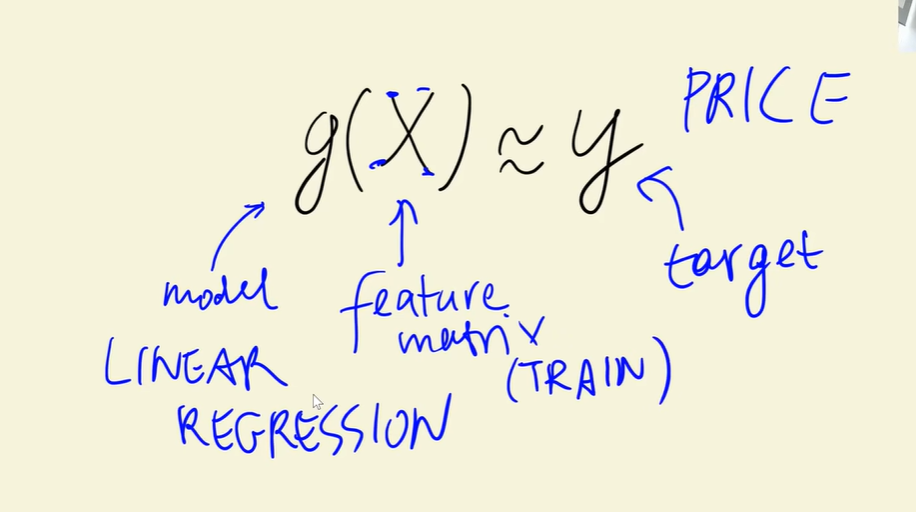

### Single observation

The goal is to create a model that will take in a list of features (characteristics of a car) and produce a good prediction (approximation) of the target (price)

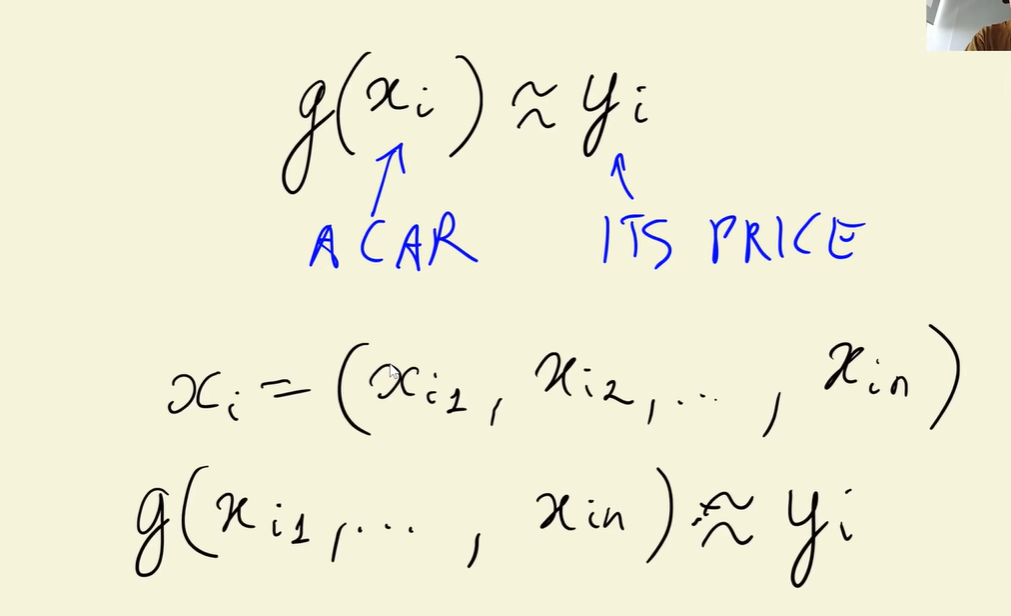

In [121]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

### Formula

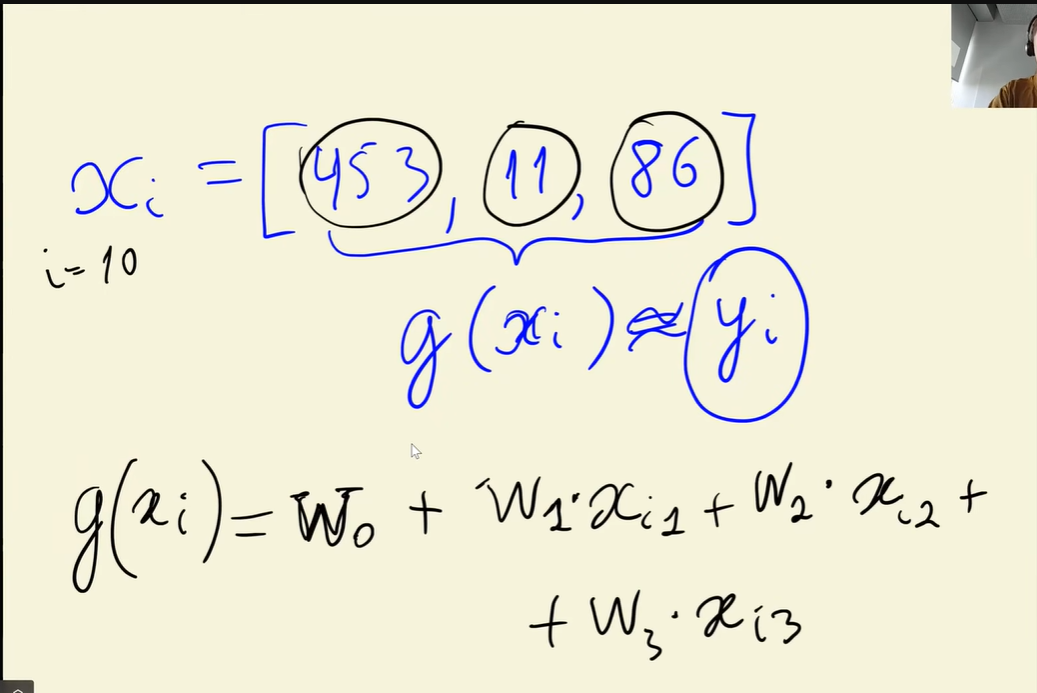

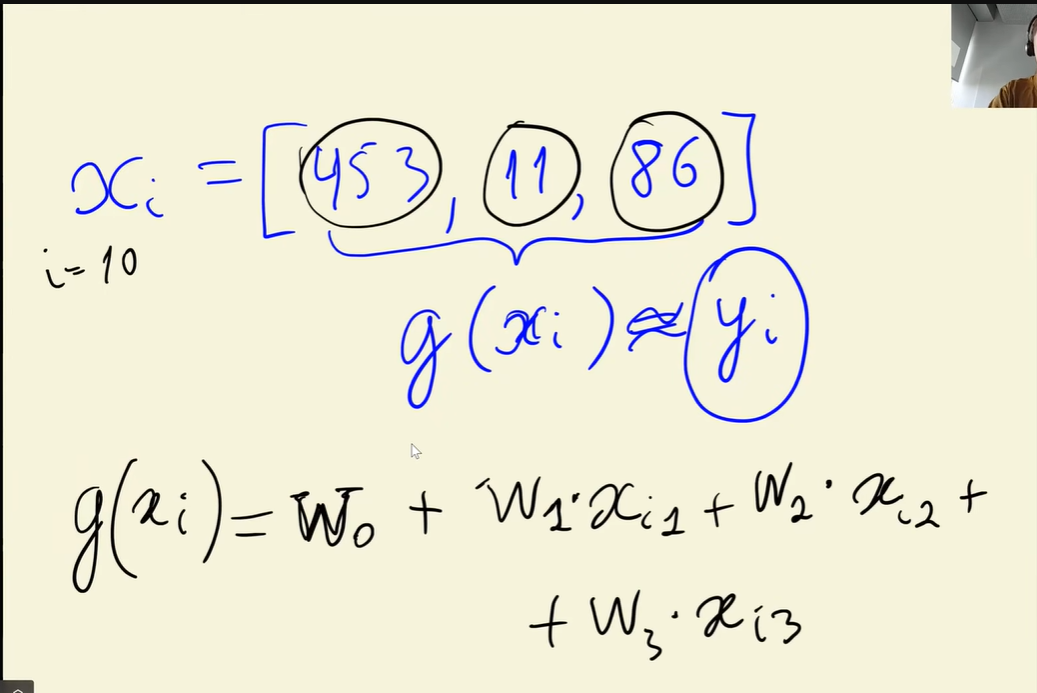

### Implementation

In [123]:
xi = df_train.loc[10, ['engine_hp', 'city_mpg', 'popularity']]
xi

engine_hp     453.0
city_mpg       11.0
popularity     86.0
Name: 10, dtype: float64

In [136]:
# In practice, the bias and weights values would be learned from training data
bias = 7.17
weights = [0.01, 0.04, 0.002]

def linear_regression(xi):
    n = len(xi)

    # Start with the bias
    pred = bias

    # For each feature, multiply the weight by the value of the feature
    for j in range(n):
        pred += weights[j] * xi.iloc[j]

    return pred


prediction = linear_regression(xi)
prediction

np.float64(12.312)

### Get the original scale using exponents

- Since we used a logarithmic transformation (`log1p`) on the target (`price`) column, the model outputs a price in log units.
- To get the value in the original units, we need to apply an exponent transformation (`expm1`) to reverse the log transformation.

In [138]:
original_price = np.expm1(prediction).round(2)
original_price

np.float64(222347.22)

## Linear Regression (Vector Form)